# 03 - Model Training

- Load the processed training and validation datasets
- Separate the features and target variable
- Train different machine learning models
- Evaluate each model on the validation set
- Save the trained models

#### Import libraries

In [1]:
import os
import random
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from torch.utils.data import DataLoader, TensorDataset
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

#### Set the random seed

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

#### Load the processed datasets

In [3]:
train_data = pd.read_csv("../DataSet/processed/telco_churn_train.csv")
validation_data = pd.read_csv("../DataSet/processed/telco_churn_validation.csv")

#### Check the dataset size

In [4]:
print("Training data:", train_data.shape)
print("Validation data:", validation_data.shape)

Training data: (4922, 47)
Validation data: (1055, 47)


#### Preview the training data

In [5]:
train_data.head()

,tenure,MonthlyCharges,TotalCharges,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,PhoneService_No,...,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,SeniorCitizen_0,SeniorCitizen_1,Churn
0,-0.833469,0.444749,-0.607066,1.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1
1,-0.508058,-1.492135,-0.823672,0.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0
2,-1.240233,-0.120451,-0.950975,1.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0
3,0.061411,-0.021293,-0.081500,1.0,0.0,0.0,1.0,1.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0
4,-0.833469,1.166949,-0.495086,1.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1


#### Separate the features and target

In [6]:
X_train = train_data.drop(columns=["Churn"])
y_train = train_data["Churn"]

X_validation = validation_data.drop(columns=["Churn"])
y_validation = validation_data["Churn"]

#### Check the feature and target shapes

In [7]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_validation:", X_validation.shape)
print("y_validation:", y_validation.shape)

X_train: (4922, 46)
y_train: (4922,)
X_validation: (1055, 46)
y_validation: (1055,)


#### Create a function to evaluate each model

In [8]:
def evaluate_model(model_name, model, X, y):
    predictions = model.predict(X)
    probabilities = model.predict_proba(X)[:, 1]

    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(y, predictions),
        "Precision": precision_score(y, predictions),
        "Recall": recall_score(y, predictions),
        "F1-Score": f1_score(y, predictions),
        "ROC-AUC": roc_auc_score(y, probabilities)
    }

    return results

#### Train Logistic Regression

In [9]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=SEED
)

logistic_model.fit(X_train, y_train)

print("Logistic Regression training completed.")

Logistic Regression training completed.


#### Evaluate Logistic Regression

In [10]:
logistic_results = evaluate_model(
    "Logistic Regression",
    logistic_model,
    X_validation,
    y_validation
)

logistic_results

{'Model': 'Logistic Regression',
 'Accuracy': 0.8236966824644549,
 'Precision': 0.6938775510204082,
 'Recall': 0.604982206405694,
 'F1-Score': 0.6463878326996197,
 'ROC-AUC': 0.8532856078788381}

#### Train Decision Tree

In [11]:
decision_tree_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=SEED
)

decision_tree_model.fit(X_train, y_train)

print("Decision Tree training completed.")

Decision Tree training completed.


#### Evaluate Decision Tree

In [12]:
decision_tree_results = evaluate_model(
    "Decision Tree",
    decision_tree_model,
    X_validation,
    y_validation
)

decision_tree_results

{'Model': 'Decision Tree',
 'Accuracy': 0.8,
 'Precision': 0.6458333333333334,
 'Recall': 0.5516014234875445,
 'F1-Score': 0.5950095969289827,
 'ROC-AUC': 0.832689637415285}

#### Train Random Forest

In [13]:
random_forest_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=SEED,
    n_jobs=-1
)

random_forest_model.fit(X_train, y_train)

print("Random Forest training completed.")

Random Forest training completed.


#### Evaluate Random Forest

In [14]:
random_forest_results = evaluate_model(
    "Random Forest",
    random_forest_model,
    X_validation,
    y_validation
)

random_forest_results

{'Model': 'Random Forest',
 'Accuracy': 0.8009478672985783,
 'Precision': 0.6682464454976303,
 'Recall': 0.501779359430605,
 'F1-Score': 0.573170731707317,
 'ROC-AUC': 0.8437543104637368}

#### Train Multi-Layer Perceptron

In [15]:
mlp_model = MLPClassifier(
    hidden_layer_sizes=(64,),
    activation="relu",
    solver="adam",
    max_iter=500,
    early_stopping=True,
    random_state=SEED
)

mlp_model.fit(X_train, y_train)

print("MLP training completed.")

MLP training completed.


#### Evaluate Multi-Layer Perceptron

In [16]:
mlp_results = evaluate_model(
    "Multi-Layer Perceptron",
    mlp_model,
    X_validation,
    y_validation
)

mlp_results

{'Model': 'Multi-Layer Perceptron',
 'Accuracy': 0.8208530805687204,
 'Precision': 0.7149532710280374,
 'Recall': 0.5444839857651246,
 'F1-Score': 0.6181818181818182,
 'ROC-AUC': 0.8527614554884273}

In [17]:
class ChurnRNN(nn.Module):

    def __init__(
        self,
        input_size,
        hidden_size=32
    ):
        super().__init__()

        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            batch_first=True,
            nonlinearity="tanh"
        )

        self.output_layer = nn.Linear(
            hidden_size,
            1
        )

    def forward(self, x):

        _, hidden_state = self.rnn(x)

        final_hidden_state = hidden_state[-1]

        logits = self.output_layer(
            final_hidden_state
        )

        return logits.squeeze(1)


class RNNAdapter:

    def __init__(self, model):
        self.model = model

    def _prepare_data(self, X):

        if isinstance(X, pd.DataFrame):
            values = X.to_numpy(dtype=np.float32)
        else:
            values = np.asarray(
                X,
                dtype=np.float32
            )

        return torch.tensor(
            values
        ).unsqueeze(1)

    def predict_proba(self, X):

        features = self._prepare_data(X)

        self.model.eval()

        with torch.no_grad():

            logits = self.model(features)

            probabilities = torch.sigmoid(
                logits
            ).numpy()

        return np.column_stack([
            1 - probabilities,
            probabilities
        ])

    def predict(self, X):

        probabilities = self.predict_proba(X)[:, 1]

        return (
            probabilities >= 0.5
        ).astype(int)

torch.manual_seed(SEED)

X_train_rnn = torch.tensor(
    X_train.to_numpy(dtype=np.float32)
).unsqueeze(1)

y_train_rnn = torch.tensor(
    y_train.to_numpy(dtype=np.float32)
)

train_dataset = TensorDataset(
    X_train_rnn,
    y_train_rnn
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

rnn_model = ChurnRNN(
    input_size=X_train.shape[1],
    hidden_size=32
)

negative_count = (
    y_train == 0
).sum()

positive_count = (
    y_train == 1
).sum()

positive_weight = torch.tensor(
    negative_count / positive_count,
    dtype=torch.float32
)

loss_function = nn.BCEWithLogitsLoss(
    pos_weight=positive_weight
)

print(
    "Positive class weight:",
    round(positive_weight.item(), 4)
)

optimizer = torch.optim.Adam(
    rnn_model.parameters(),
    lr=0.001
)

rnn_loss_history = []

for epoch in range(15):

    rnn_model.train()
    total_loss = 0

    for batch_features, batch_labels in train_loader:

        optimizer.zero_grad()

        logits = rnn_model(
            batch_features
        )

        loss = loss_function(
            logits,
            batch_labels
        )

        loss.backward()
        optimizer.step()

        total_loss += (
            loss.item() * batch_features.size(0)
        )

    average_loss = total_loss / len(train_dataset)

    rnn_loss_history.append(
        average_loss
    )

    print(
        f"Epoch {epoch + 1}/15, "
        f"Loss: {average_loss:.4f}"
    )

print("RNN training completed.")

Positive class weight: 2.763
Epoch 1/15, Loss: 0.7963
Epoch 2/15, Loss: 0.7220
Epoch 3/15, Loss: 0.7173
Epoch 4/15, Loss: 0.7142
Epoch 5/15, Loss: 0.7127
Epoch 6/15, Loss: 0.7097
Epoch 7/15, Loss: 0.7098
Epoch 8/15, Loss: 0.7052
Epoch 9/15, Loss: 0.7037
Epoch 10/15, Loss: 0.7023
Epoch 11/15, Loss: 0.7004
Epoch 12/15, Loss: 0.7014
Epoch 13/15, Loss: 0.6994
Epoch 14/15, Loss: 0.6983
Epoch 15/15, Loss: 0.6989
RNN training completed.


In [18]:
rnn_classifier = RNNAdapter(
    rnn_model
)

rnn_results = evaluate_model(
    "Recurrent Neural Network",
    rnn_classifier,
    X_validation,
    y_validation
)

rnn_results



{'Model': 'Recurrent Neural Network',
 'Accuracy': 0.7364928909952607,
 'Precision': 0.5032679738562091,
 'Recall': 0.8220640569395018,
 'F1-Score': 0.6243243243243243,
 'ROC-AUC': 0.8524855858092636}

#### Compare the validation results

In [19]:
results = pd.DataFrame([
    logistic_results,
    decision_tree_results,
    random_forest_results,
    mlp_results,
    rnn_results
])

results

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.823697,0.693878,0.604982,0.646388,0.853286
1,Decision Tree,0.800000,0.645833,0.551601,0.595010,0.832690
2,Random Forest,0.800948,0.668246,0.501779,0.573171,0.843754
3,Multi-Layer Perceptron,0.820853,0.714953,0.544484,0.618182,0.852761
4,Recurrent Neural Network,0.736493,0.503268,0.822064,0.624324,0.852486


#### Sort the models by ROC-AUC

In [20]:
results.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.823697,0.693878,0.604982,0.646388,0.853286
1,Multi-Layer Perceptron,0.820853,0.714953,0.544484,0.618182,0.852761
2,Recurrent Neural Network,0.736493,0.503268,0.822064,0.624324,0.852486
3,Random Forest,0.800948,0.668246,0.501779,0.573171,0.843754
4,Decision Tree,0.800000,0.645833,0.551601,0.595010,0.832690


### Hyperparameter Tuning

#### Decision Tree Hyperparameter Tuning

In [21]:
decision_tree_tuning = []

for depth in [3, 5, 10]:

    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=SEED
    )

    model.fit(X_train, y_train)

    predictions = model.predict(X_validation)

    decision_tree_tuning.append({
        "Max Depth": depth,
        "Accuracy": accuracy_score(y_validation, predictions),
        "F1-Score": f1_score(y_validation, predictions)
    })

pd.DataFrame(decision_tree_tuning)

,Max Depth,Accuracy,F1-Score
0,3,0.794313,0.491803
1,5,0.800000,0.595010
2,10,0.745972,0.503704


#### Random Forest Hyperparameter Tuning

In [22]:
forest_tuning = []

for trees in [100, 200, 300]:

    model = RandomForestClassifier(
        n_estimators=trees,
        max_depth=10,
        random_state=SEED
    )

    model.fit(X_train, y_train)

    predictions = model.predict(X_validation)

    forest_tuning.append({
        "Trees": trees,
        "Accuracy": accuracy_score(y_validation, predictions),
        "F1-Score": f1_score(y_validation, predictions)
    })

pd.DataFrame(forest_tuning)

,Trees,Accuracy,F1-Score
0,100,0.800000,0.572008
1,200,0.800948,0.573171
2,300,0.799052,0.567347


#### Multi-Layer Perceptron Hyperparameter Tuning

In [23]:
mlp_tuning = []

for layers in [(32,), (64,), (64, 32)]:

    model = MLPClassifier(
        hidden_layer_sizes=layers,
        activation="relu",
        solver="adam",
        max_iter=500,
        early_stopping=True,
        random_state=SEED
    )

    model.fit(X_train, y_train)

    predictions = model.predict(X_validation)

    mlp_tuning.append({
        "Hidden Layers": str(layers),
        "Accuracy": accuracy_score(y_validation, predictions),
        "F1-Score": f1_score(y_validation, predictions)
    })

pd.DataFrame(mlp_tuning)

,Hidden Layers,Accuracy,F1-Score
0,"(32,)",0.787678,0.539095
1,"(64,)",0.820853,0.618182
2,"(64, 32)",0.804739,0.600775


In [24]:
rnn_tuning = []
rnn_candidates = {}

for hidden_size in [16, 32, 64]:

    torch.manual_seed(SEED)

    candidate_model = ChurnRNN(
        input_size=X_train.shape[1],
        hidden_size=hidden_size
    )

    loss_function = nn.BCEWithLogitsLoss(
        pos_weight=positive_weight
    )

    optimizer = torch.optim.Adam(
        candidate_model.parameters(),
        lr=0.001
    )

    candidate_loss_history = []

    for epoch in range(15):

        candidate_model.train()
        total_loss = 0

        for batch_features, batch_labels in train_loader:

            optimizer.zero_grad()

            logits = candidate_model(
                batch_features
            )

            loss = loss_function(
                logits,
                batch_labels
            )

            loss.backward()
            optimizer.step()

            total_loss += (
                loss.item()
                * batch_features.size(0)
            )

        average_loss = (
            total_loss / len(train_dataset)
        )

        candidate_loss_history.append(
            average_loss
        )

    candidate_classifier = RNNAdapter(
        candidate_model
    )

    candidate_results = evaluate_model(
        f"RNN ({hidden_size} hidden units)",
        candidate_classifier,
        X_validation,
        y_validation
    )

    rnn_tuning.append({
        "Hidden Size": hidden_size,
        "Accuracy": candidate_results["Accuracy"],
        "Precision": candidate_results["Precision"],
        "Recall": candidate_results["Recall"],
        "F1-Score": candidate_results["F1-Score"],
        "ROC-AUC": candidate_results["ROC-AUC"]
    })

    rnn_candidates[hidden_size] = {
        "Model": candidate_model,
        "Results": candidate_results,
        "Loss History": candidate_loss_history
    }

rnn_tuning_results = pd.DataFrame(
    rnn_tuning
)

rnn_tuning_results

best_hidden_size = rnn_tuning_results.loc[
    rnn_tuning_results["ROC-AUC"].idxmax(),
    "Hidden Size"
]

best_hidden_size = int(best_hidden_size)

rnn_model = rnn_candidates[
    best_hidden_size
]["Model"]

rnn_loss_history = rnn_candidates[
    best_hidden_size
]["Loss History"]

rnn_classifier = RNNAdapter(
    rnn_model
)

rnn_results = evaluate_model(
    "Recurrent Neural Network",
    rnn_classifier,
    X_validation,
    y_validation
)

print(
    "Best RNN hidden size:",
    best_hidden_size
)

rnn_results

Best RNN hidden size: 32


{'Model': 'Recurrent Neural Network',
 'Accuracy': 0.7364928909952607,
 'Precision': 0.5032679738562091,
 'Recall': 0.8220640569395018,
 'F1-Score': 0.6243243243243243,
 'ROC-AUC': 0.8524855858092636}

## Regularization

The models use different methods to reduce overfitting.

- Logistic Regression uses L2 regularization.
- Decision Tree limits the tree depth using `max_depth`.
- Random Forest also limits tree depth.
- The Multi-Layer Perceptron uses early stopping during training.

#### MLP Training Loss

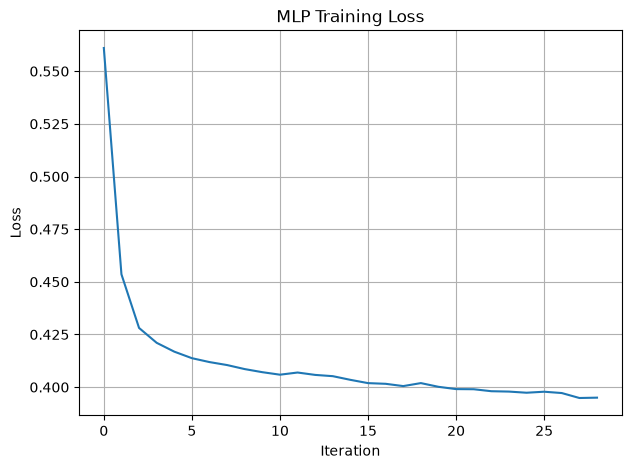

In [25]:
plt.figure(figsize=(7, 5))

plt.plot(mlp_model.loss_curve_)

plt.title("MLP Training Loss")
plt.xlabel("Iteration")
plt.ylabel("Loss")

plt.grid(True)

plt.show()

#### RNN Training Loss

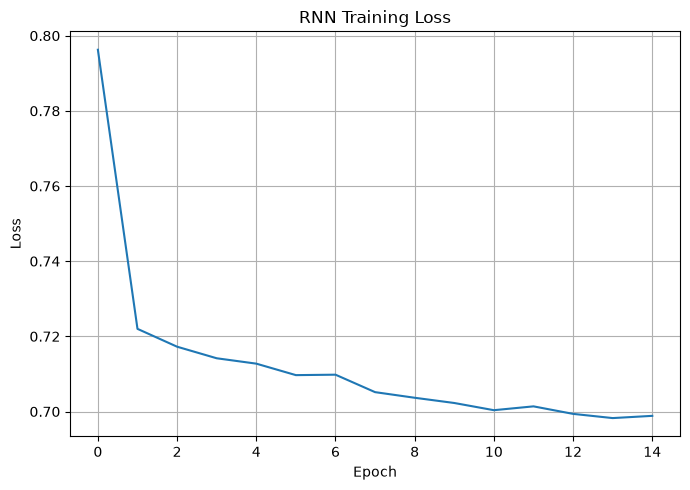

In [26]:
plt.figure(figsize=(7, 5))

plt.plot(
    rnn_loss_history,
)

plt.title("RNN Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.grid(True)
plt.tight_layout()
plt.show()

Different hyperparameter values were tested for the Decision Tree, Random Forest, Multi-Layer Perceptron, and Recurrent Neural Network models. The final settings were selected based on their performance on the validation dataset. These settings were then used to train the final models saved in this project.

#### Save the trained models

In [27]:
os.makedirs("../models", exist_ok=True)

joblib.dump(
    logistic_model,
    "../models/logistic_regression.joblib"
)

joblib.dump(
    decision_tree_model,
    "../models/decision_tree.joblib"
)

joblib.dump(
    random_forest_model,
    "../models/random_forest.joblib"
)

joblib.dump(
    mlp_model,
    "../models/mlp.joblib"
)

torch.save(
    rnn_model.state_dict(),
    "../models/rnn.pth"
)

print("All trained models saved successfully.")

All trained models saved successfully.


#### Save the validation results

In [28]:
results.to_csv(
    "../models/validation_results.csv",
    index=False
)

print("Validation results saved successfully.")

Validation results saved successfully.


#### Summary

Four classification models were trained and evaluated using the validation set:

The models were compared on the validation dataset using accuracy, precision, recall, F1-score, and ROC-AUC. Hyperparameter tuning was performed for the Decision Tree, Random Forest, and Multi-Layer Perceptron models. Regularization techniques such as limiting tree depth and early stopping were used to reduce overfitting. The trained models and validation results were saved for use in the final evaluation notebook.